In [2]:
import numpy as np
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display
from networkx.drawing.nx_agraph import graphviz_layout

In [3]:
def KL(p, q):
  S = 0
  for i in range(len(p)):
    if p[i] != 0:
      S += p[i]*np.log(p[i]/q[i])
  return S

In [5]:
# ----------------------------
# Step 1: Trace function
# ----------------------------

def bubble_sort_trace_from_state(init_state):
    """
    Simulates execution of Bubble Sort from an arbitrary initial state.
    Returns a list of state vectors at each step:
    [arr copy, i, j, swapped, PC]
    """
    arr_init = init_state
    trace = []

    # Make a copy of array so we don't modify original
    arr = list(arr_init)
    n = len(arr)
    i = 0
    j = 0
    swapped = False
    PC = 0

    while True:
        trace.append([arr.copy(), i, j, swapped, PC])

        if PC == 0:
            # Start of outer loop
            PC = 1

        elif PC == 1:
            if i >= n:
                PC = 7  # Halt
            else:
                swapped = False
                j = 0
                PC = 2

        elif PC == 2:
            # Inner loop
            if j >= n - i - 1:
                PC = 6  # End of outer loop iteration
            else:
                PC = 3  # Compare elements

        elif PC == 3:
            # Compare arr[j] and arr[j+1]
            if arr[j] > arr[j+1]:
                PC = 4
            else:
                PC = 5  # Skip swap

        elif PC == 4:
            # Swap
            arr[j], arr[j+1] = arr[j+1], arr[j]
            swapped = True
            PC = 5

        elif PC == 5:
            # Increment inner loop index
            j += 1
            PC = 2

        elif PC == 6:
            # End of outer loop iteration
            if not swapped:
                PC = 7  # Halt
            else:
                i += 1
                PC = 1

        elif PC == 7:
            # Halt
            trace.append([arr.copy(), i, j, swapped, PC])
            break

    return trace

# Example: initial state with outer loop i=0, inner loop j=0, swapped=True, PC=0
# trace_example = bubble_sort_trace_from_state([3,1,2])
# for t in trace_example:
#     print(t)


### I. No repeating entries (permutations)

In [6]:
# --------------------------------------------------------
# Step 2: Compute the State space and/or associated map G
# --------------------------------------------------------

def program_map_G_perm(n):
  all_states = []
  state_traces = [] # This will now store flattened traces
  arr_perms = itertools.permutations(range(1, n+1))
  for arr_initial in arr_perms:
    # Call the bubble sort trace function. The version in NK8hJEVTunNt
    # returns states as: [list of array elements, i, j, swapped, PC]
    trace_raw = bubble_sort_trace_from_state(list(arr_initial))

    current_trace_flattened = []
    for state in trace_raw:
        arr_part = list(state[0]) # Get the array as a list
        i_val = state[1]
        j_val = state[2]
        swapped_val = int(state[3]) # Convert boolean 'swapped' to int for numerical consistency
        pc_val = state[4]

        # Flatten the state into a single list of numbers
        flattened_state = arr_part + [i_val, j_val, swapped_val, pc_val]
        current_trace_flattened.append(flattened_state)

    state_traces.append(current_trace_flattened) # Store the flattened trace
    all_states.extend(current_trace_flattened) # Extend the master list with flattened states

  # Now, all_states is a list of lists, where each inner list is a flat sequence of numbers.
  # np.array(all_states) should now work correctly.
  all_states = np.array(all_states)
  be = np.arange(all_states.shape[1]) + np.random.uniform(size=all_states.shape[1])
  hashes = np.dot(all_states, be)
  unique_hashes, inverse_indices = np.unique(hashes, return_inverse=True)
  hash_dict = {h: i for i, h in enumerate(unique_hashes)}

  # ----------------------------
  # Step 3: Build adjacency matrix
  # ----------------------------
  G = np.zeros((len(unique_hashes), len(unique_hashes)), dtype=int)
  pos_cen = []

  global_idx = 0 # Initialize a counter for the index in the flattened all_states array

  for trace in state_traces:
    L = len(trace)
    for u in range(L):
        # Get the unique hash index for the current state in the trace
        # It corresponds to the state at position `global_idx` in the `all_states` array.
        n1 = inverse_indices[global_idx]

        if u < L-1:
            # Get the unique hash index for the next state in the trace
            # It corresponds to the state at position `global_idx + 1` in the `all_states` array.
            n2 = inverse_indices[global_idx + 1]
        else:
            n2 = n1
            pos_cen.append(n1)

        G[n1, n2] = 1
        global_idx += 1 # Increment global_idx for the next state in all_states
  return G, len(unique_hashes)

In [7]:
# ---------------------------------
# Step 3: Compute the mismatch cost
# ---------------------------------

MMC_perm_acc = []
MMC_perm = []
for n in range(2, 5):
  G, size = program_map_G_perm(n)
  q0 = np.ones(size) / size

  p0 = np.ones(size) / size

  q1 = G.T@q0
  MMCn = []
  MMCk = []
  mmc = 0
  for t in range(60):
    p1 = G.T@p0
    k = KL(p0, q0)-KL(p1, q1)
    mmc += k
    MMCn.append(mmc)
    MMCk.append(k)
    p0 = p1

  MMC_perm_acc.append(MMCn)
  MMC_perm.append(MMCk)
  print(n)

2
3
4


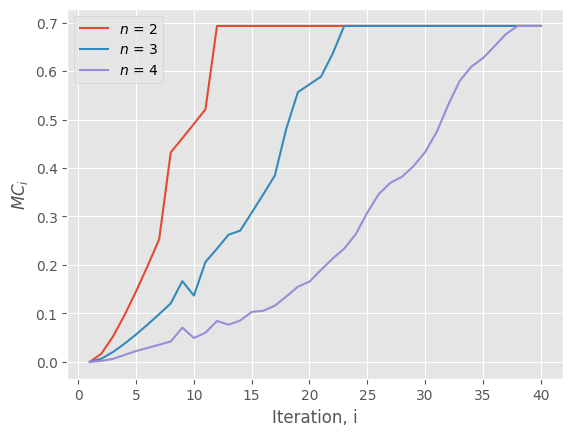

In [36]:
# -------------
# Step 4: Plot
# -------------

plt.style.use('ggplot')

for i in range(3):
  plt.plot(range(1, 41), MMC_perm[i][:40], label = r'$n$ = '+str(i+2))
  #plt.scatter(range(1, 41), MMC_perm[i][:40], s = 4)
# plt.scatter(range(1, 7), MMC)
# plt.plot(range(1, 7), MMC)
#plt.ylim(0, 2.1)
plt.ylabel(r'$MC_i$')
plt.xlabel('Iteration, i')
plt.legend()
plt.savefig("MMC_bubblesort_perm.pdf", format='pdf', bbox_inches='tight')

### II. Repeating entries (combination)

In [13]:
# --------------------------------------------------------
# Step 2: Compute the State space and/or associated map G
# --------------------------------------------------------

def program_map_G_comb(n):
  values = np.arange(1, n+1, 1)  # possible values for each slot
  length = n
  all_states = []
  state_traces = [] # This will now store flattened traces
  arr_perms = list(itertools.product(values, repeat=length))
  for arr_initial in arr_perms:
    # Call the bubble sort trace function. The version in NK8hJEVTunNt
    # returns states as: [list of array elements, i, j, swapped, PC]
    trace_raw = bubble_sort_trace_from_state(list(arr_initial))

    current_trace_flattened = []
    for state in trace_raw:
        arr_part = list(state[0]) # Get the array as a list
        i_val = state[1]
        j_val = state[2]
        swapped_val = int(state[3]) # Convert boolean 'swapped' to int for numerical consistency
        pc_val = state[4]

        # Flatten the state into a single list of numbers
        flattened_state = arr_part + [i_val, j_val, swapped_val, pc_val]
        current_trace_flattened.append(flattened_state)

    state_traces.append(current_trace_flattened) # Store the flattened trace
    all_states.extend(current_trace_flattened) # Extend the master list with flattened states

  # Now, all_states is a list of lists, where each inner list is a flat sequence of numbers.
  # np.array(all_states) should now work correctly.
  all_states = np.array(all_states)
  be = np.arange(all_states.shape[1]) + np.random.uniform(size=all_states.shape[1])
  hashes = np.dot(all_states, be)
  unique_hashes, inverse_indices = np.unique(hashes, return_inverse=True)
  hash_dict = {h: i for i, h in enumerate(unique_hashes)}

  # ----------------------------
  # Step 3: Build adjacency matrix
  # ----------------------------
  G = np.zeros((len(unique_hashes), len(unique_hashes)), dtype=int)
  pos_cen = []

  global_idx = 0 # Initialize a counter for the index in the flattened all_states array

  for trace in state_traces:
    L = len(trace)
    for u in range(L):
        # Get the unique hash index for the current state in the trace
        # It corresponds to the state at position `global_idx` in the `all_states` array.
        n1 = inverse_indices[global_idx]

        if u < L-1:
            # Get the unique hash index for the next state in the trace
            # It corresponds to the state at position `global_idx + 1` in the `all_states` array.
            n2 = inverse_indices[global_idx + 1]
        else:
            n2 = n1
            pos_cen.append(n1)

        G[n1, n2] = 1
        global_idx += 1 # Increment global_idx for the next state in all_states
  return G, len(unique_hashes)

In [14]:
# ---------------------------------
# Step 3: Compute the mismatch cost
# ---------------------------------

MMC_comb_acc = []
MMC_comb = []
for n in range(2, 5):
  G, size = program_map_G_comb(n)
  q0 = np.ones(size) / size

  p0 = np.ones(size) / size

  q1 = G.T@q0
  MMCn = []
  MMCk = []
  mmc = 0
  for t in range(100):
    p1 = G.T@p0
    k = KL(p0, q0)-KL(p1, q1)
    mmc += k
    MMCn.append(mmc)
    MMCk.append(k)
    p0 = p1

  MMC_comb_acc.append(MMCn)
  MMC_comb.append(MMCk)
  print(n)

2
3
4


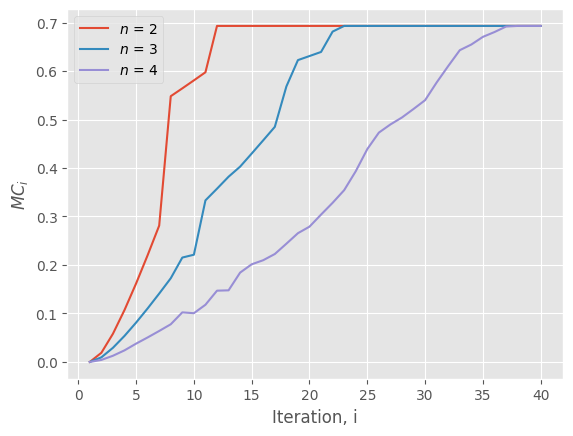

In [37]:
# -------------
# Step 4: Plot
# -------------

plt.style.use('ggplot')

for i in range(3):
  plt.plot(range(1, 41), MMC_comb[i][:40], label = r'$n$ = '+str(i+2))
  #plt.scatter(range(1, 41), MMC_comb[i][:40], s = 2)
# plt.scatter(range(1, 7), MMC)
# plt.plot(range(1, 7), MMC)
#plt.ylim(0, 2.1)
plt.ylabel(r'$MC_i$')
plt.xlabel('Iteration, i')
plt.legend()
plt.savefig("MMC_bubblesort_comb.pdf", format='pdf', bbox_inches='tight')

In [32]:
total_mmc_comb = [MMC_comb_acc[0][12], MMC_comb_acc[1][23], MMC_comb_acc[2][37]]

In [27]:
total_mmc_perm = [MMC_perm_acc[0][10], MMC_perm_acc[1][23], MMC_perm_acc[2][38]]

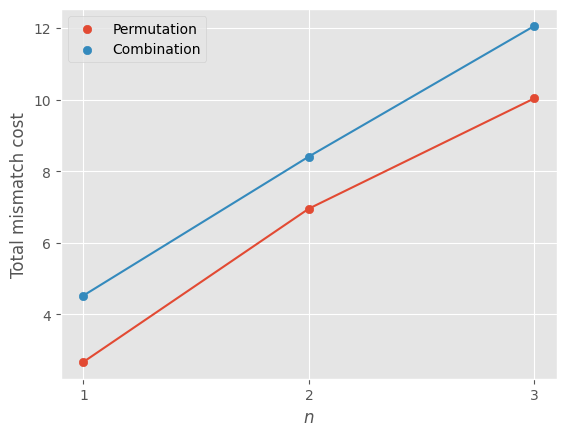

In [35]:
plt.scatter(range(1, 4), total_mmc_perm, label = "Permutation")
plt.plot(range(1, 4), total_mmc_perm)

plt.scatter(range(1, 4), total_mmc_comb, label = "Combination")
plt.plot(range(1, 4), total_mmc_comb)
plt.savefig("MMC_bubblesort_total.pdf", format='pdf', bbox_inches='tight')
plt.xlabel(r'$n$')
plt.xticks(range(1, 4))
plt.ylabel("Total mismatch cost")
plt.legend()